# Mode III near-tip fields: stress singularity vs. displacement field

This notebook illustrates, with sympy and matplotlib, the two faces of the
same Mode III crack-tip solution (`ModeIII_singular_behaviour.mw`,
`ModeIII_diplacements_vonMises.mw`): the **stress field**, which is singular
at the crack tip, and the **displacement field**, which stays finite and
continuous there but has an infinite slope. Seeing both side by side is the
clearest way to motivate why $K$ (not stress or displacement alone) is the
natural quantity to characterise the crack-tip state.

Setup: a crack of length $2a$ in an infinite plate under remote anti-plane
shear $\tau_0$, analysed with the complex stress function
$$
h(z) = \tau_0\sqrt{z^2-a^2}, \qquad z=x_1+ix_2,
$$
giving stresses $\sigma_{32}+i\sigma_{31}=h'(z)$ and out-of-plane
displacement $w(z) = \mathrm{Im}(h(z))/\mu$.

Run it however is easiest for you:

- **In a browser, nothing installed:**
  https://cfni-dtu.github.io/41526-notebooks/lab/index.html?path=lecture03/ModeIII_singular_behaviour.ipynb
- **Locally**, with any Jupyter install
  (`pip install numpy matplotlib sympy jupyterlab`, then `jupyter lab`).

See also the companion notebook on the Mode III **plastic zone**
(`ModeIII_plastic_zone.ipynb`), which uses the same near-tip
stress field derived here.


In [ ]:
try:
    import sympy as sp
except ImportError:
    import micropip
    await micropip.install("sympy")
    import sympy as sp

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.seterr(invalid='ignore', over='ignore')  # keep divide-by-zero visible

# The default inline-figure capture crops with bbox_inches='tight', which
# mishandles rotated 3D z-axis labels and cuts them off; disable that here.
# (Kept in its own cell: jupyterlite-pyodide-kernel's package auto-loader
# statically parses each cell for import statements before executing it, and
# a magic like %config isn't valid Python, so on a fresh kernel it can't parse
# a cell that mixes the two and silently skips preloading numpy/matplotlib.)
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

sp.init_printing()

## Step 1 — the complex stress function, symbolically

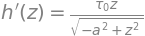

In [2]:
z, a, tau0, mu = sp.symbols('z a tau_0 mu', positive=True)
x1, x2 = sp.symbols('x1 x2', real=True)

h = tau0*sp.sqrt(z**2 - a**2)
hprime = sp.diff(h, z)

display(sp.Eq(sp.Function('h')(z), h))
display(sp.Eq(sp.Symbol("h'(z)"), hprime))

subs_num = {tau0: 1, a: 1, mu: 1}  # concrete values reused in every numeric plot below


*Note:* $\sqrt{z^2-a^2}$ is multivalued, so the numerical square root
needs a $\mathrm{sign}(x_1)$ correction to give the physically correct
field instead of an artificially antisymmetric one — used in the exact-field
plots in Steps 3-4 below.

## Step 2 — near-tip behaviour: $r^{-1/2}$ stress vs. $r^{1/2}$ displacement

Writing $z=a+re^{i\theta}$ and expanding for small $r$ gives the leading
(singular) behaviour of the stress field, and the leading behaviour of the
displacement field, in terms of the stress intensity factor
$K_{III}=\tau_0\sqrt{\pi a}$:


In [3]:
r, theta = sp.symbols('r theta', positive=True)
K3 = tau0*sp.sqrt(sp.pi*a)

sigma32_sing = K3/sp.sqrt(2*sp.pi*r)*sp.cos(theta/2)
w_lead = (K3/mu)*sp.sqrt(2*r/sp.pi)*sp.sin(theta/2)

display(sp.Eq(sp.Symbol('sigma_32__sing'), sigma32_sing))
display(sp.Eq(sp.Symbol('w__lead'), w_lead))


Plotted as 3-D surfaces in local coordinates centred on the tip, the
contrast is immediate: the stress term rises to a sharp spike at the tip,
while the displacement term forms a smooth ridge that reaches zero exactly
at the tip but with an infinite slope.


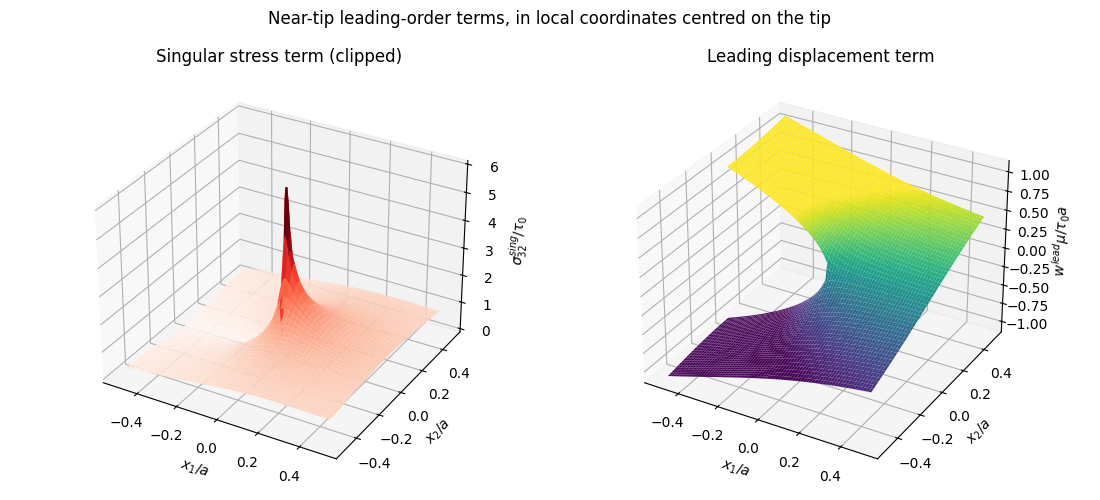

In [4]:
sigma32_sing_f = sp.lambdify((r, theta), sigma32_sing.subs(subs_num), 'numpy')
w_lead_f = sp.lambdify((r, theta), w_lead.subs(subs_num), 'numpy')

def local_surface(f, x1_vals, x2_vals, clip=None):
    X1_, X2_ = np.meshgrid(x1_vals, x2_vals)
    R_ = np.sqrt(X1_**2 + X2_**2)
    Theta_ = np.arctan2(X2_, X1_)
    val = f(R_, Theta_)
    if clip is not None:
        val = np.clip(val, *clip)
    return X1_, X2_, val

x1_full = np.linspace(-0.5, 0.5, 150)
x1_behind = np.linspace(-0.5, 0, 75)
x2_full = np.linspace(-0.5, 0.5, 150)
x2_upper = np.linspace(0.01, 0.5, 75)
x2_lower = np.linspace(-0.5, -0.01, 75)

fig = plt.figure(figsize=(11, 5))

# Singular stress term: continuous everywhere (cos(theta/2)=0 at theta=+-pi
# vanishes smoothly), so it needs no split.
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(*local_surface(sigma32_sing_f, x1_full, x2_full, clip=(0, 6)),
                  cmap='Reds', linewidth=0, antialiased=True)
ax1.set_xlabel(r'$x_1/a$')
ax1.set_ylabel(r'$x_2/a$')
ax1.set_zlabel(r'$\sigma_{32}^{sing}/\tau_0$')
ax1.set_title('Singular stress term (clipped)')

# Leading displacement term is continuous ahead of the tip, but jumps
# across the crack face behind it (theta=+-pi): three connected patches
# (one ahead, two behind split by the crack) instead of one full-width split.
ax2 = fig.add_subplot(122, projection='3d')
kwargs = dict(cmap='viridis', linewidth=0, antialiased=True, vmin=-0.6, vmax=0.6)
ax2.plot_surface(*local_surface(w_lead_f, np.linspace(0, 0.5, 75), x2_full), **kwargs)
ax2.plot_surface(*local_surface(w_lead_f, x1_behind, x2_upper), **kwargs)
ax2.plot_surface(*local_surface(w_lead_f, x1_behind, x2_lower), **kwargs)
ax2.set_xlabel(r'$x_1/a$')
ax2.set_ylabel(r'$x_2/a$')
ax2.set_zlabel(r'$w^{lead}\mu/\tau_0 a$')
ax2.set_title('Leading displacement term')

fig.suptitle('Near-tip leading-order terms, in local coordinates centred on the tip')
fig.tight_layout()
plt.show()


## Step 3 — full stress field: von Mises contours around both crack tips

Away from the immediate vicinity of the tips the exact field must be used.
Using $\sigma_{32}=\mathrm{Re}(h'(z))$, $\sigma_{31}=\mathrm{Im}(h'(z))$ and
$\sigma_e=\sqrt{3(\sigma_{32}^2+\sigma_{31}^2)}$ (as in the Mode III plastic zone notebook), we plot
contours of $\sigma_e$ over the whole plate, seeing both crack tips (at
$x_1=\pm a$) as singular points and the interior of the crack
($|x_1|<a,\,x_2=0$) as unstressed.


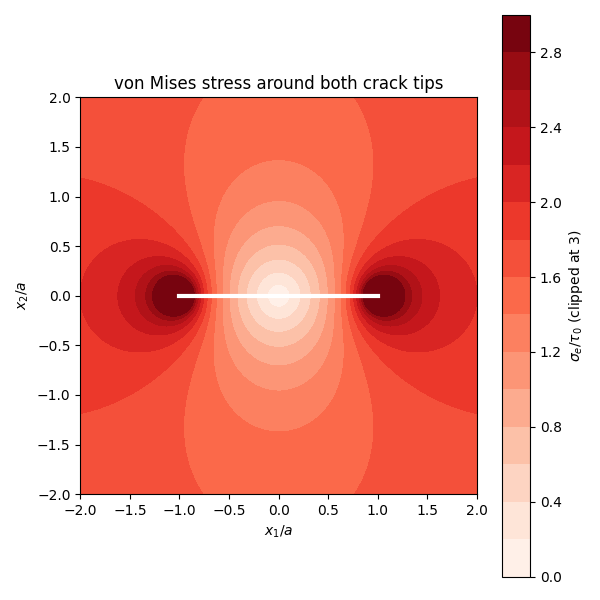

In [5]:
hprime_num = sp.lambdify(z, hprime.subs(subs_num), 'numpy')

X1, X2 = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-2, 2, 400))
Hp = hprime_num(X1 + 1j*X2)
sigma_e = np.sqrt(3*(Hp.real**2 + Hp.imag**2))

fig, ax = plt.subplots(figsize=(6, 6))
levels = np.linspace(0, 3, 16)
cs = ax.contourf(X1, X2, np.clip(sigma_e, 0, 3), levels=levels, cmap='Reds')
ax.plot([-1, 1], [0, 0], color='white', lw=3)  # mask the crack line itself
fig.colorbar(cs, ax=ax, label=r'$\sigma_e/\tau_0$ (clipped at 3)')
ax.set_xlabel(r'$x_1/a$')
ax.set_ylabel(r'$x_2/a$')
ax.set_aspect('equal')
ax.set_title('von Mises stress around both crack tips')
fig.tight_layout()
plt.show()


## Step 4 — the displacement field: crack opening and localised disturbance

First, the full out-of-plane displacement $w=\mathrm{sign}(x_1)\,\mathrm{Im}(h(z))/\mu$
(branch-corrected as above). Far from the crack it is the linear ramp
$w\approx\tau_0 x_2/\mu$ expected from the remote shear; near the crack it
twists to open the crack faces:


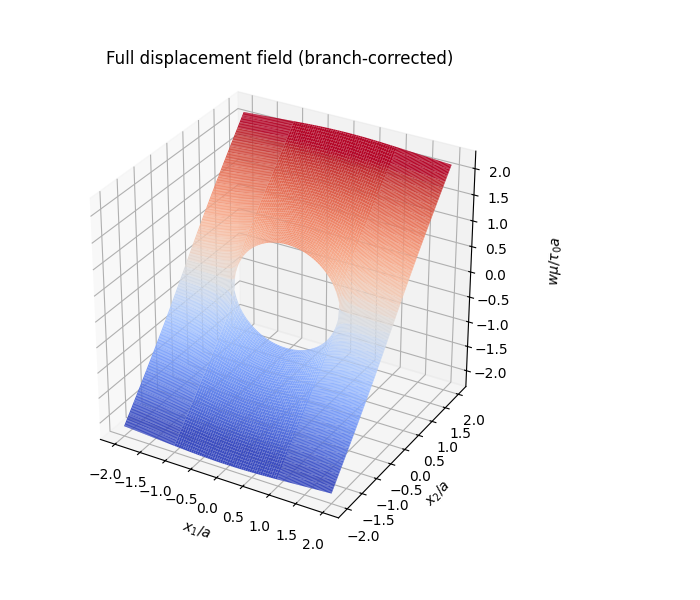

In [6]:
h_num = sp.lambdify(z, h.subs(subs_num), 'numpy')

def w_field(X1_, X2_):
    return np.sign(X1_) * h_num(X1_ + 1j*X2_).imag

def w_patches(gap=0.02, n=100):
    """Continuous surface away from the crack; split with a small gap across it."""
    x1_left = np.linspace(-2, -1, n)
    x1_crack = np.linspace(-1, 1, n)
    x1_right = np.linspace(1, 2, n)
    x2_full = np.linspace(-2, 2, 2*n)
    x2_up = np.linspace(gap, 2, n)
    x2_dn = np.linspace(-2, -gap, n)

    patches = [np.meshgrid(x1_left, x2_full), np.meshgrid(x1_right, x2_full)]
    patches += [np.meshgrid(x1_crack, x2_up), np.meshgrid(x1_crack, x2_dn)]
    return patches

patches = w_patches()

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
for X1p, X2p in patches:
    ax.plot_surface(X1p, X2p, w_field(X1p, X2p), cmap='coolwarm', linewidth=0, antialiased=True, vmin=-2, vmax=2)
ax.set_box_aspect((1, 1, 1))  # true-to-scale: z-range here matches the x1/x2 range
ax.set_xlabel(r'$x_1/a$')
ax.set_ylabel(r'$x_2/a$')
ax.set_zlabel(r'$w\mu/\tau_0 a$', labelpad=20)
ax.set_title('Full displacement field (branch-corrected)')
fig.subplots_adjust(left=0.05, right=0.75)
plt.show()


Subtracting the far-field ramp $x_2$ isolates the **disturbance caused
by the crack alone** — it should decay to zero away from the crack, leaving
a localised dip:


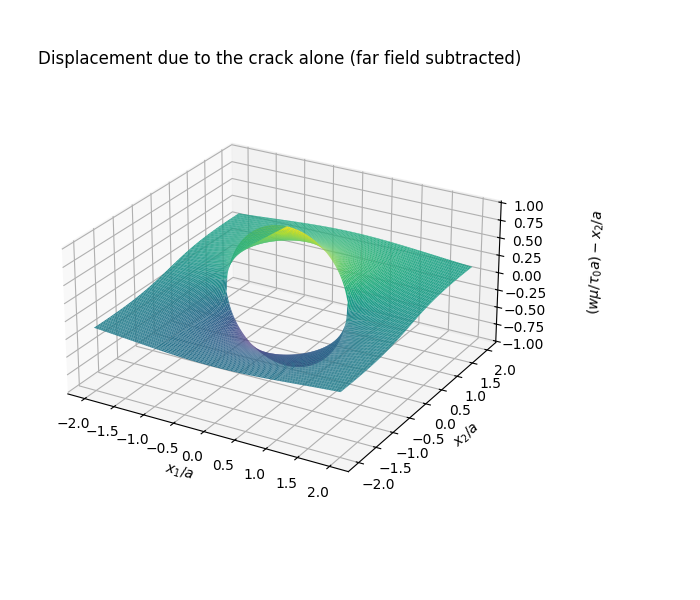

In [7]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
for X1p, X2p in patches:
    ax.plot_surface(X1p, X2p, w_field(X1p, X2p) - X2p, cmap='viridis', linewidth=0, antialiased=True, vmin=-1, vmax=1)
ax.set_box_aspect((2, 2, 1))  # true-to-scale: this z-range is half the x1/x2 range
ax.set_xlabel(r'$x_1/a$')
ax.set_ylabel(r'$x_2/a$')
ax.set_zlabel(r'$(w\mu/\tau_0 a) - x_2/a$', labelpad=20)
ax.set_title('Displacement due to the crack alone (far field subtracted)')
ax.view_init(elev=25, azim=-60)
fig.subplots_adjust(left=0.05, right=0.75)
plt.show()


## Takeaways

- The stress field is **singular**: $\sigma\sim K_{III}/\sqrt{2\pi r}\to\infty$
  as $r\to0$. This is why LEFM needs a plastic zone correction (see the
  Mode III plastic zone notebook) — no real material can sustain infinite stress.
- The displacement field is **finite and continuous** at the tip, but its
  slope diverges ($w\sim\sqrt{r}$): the crack faces meet in a smooth
  parabolic profile, not a sharp wedge and not a jump.
- Both behaviours are governed by the *same* single parameter, $K_{III}$ —
  which is precisely why $K$, rather than a stress or a displacement value,
  is the right quantity to characterise the crack-tip field.
- The principal-branch sign flip in $\sqrt{z^2-a^2}$ is a good concrete
  example of why care is needed with multivalued complex functions in this
  kind of analysis.
